In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("yelp_dataset_csv/yelp_academic_dataset_checkin.csv")
df.head()

,business_id,date
0,---kPU91CF4Lq2-WlRu9Lw,"2020-03-13 21:10:56, 2020-06-02 22:18:06, 2020..."
1,--0iUa4sNDFiZFrAdIWhZQ,"2010-09-13 21:43:09, 2011-05-04 23:08:15, 2011..."
2,--30_8IhuyMHbSOcNWd6DQ,"2013-06-14 23:29:17, 2014-08-13 23:20:22"
3,--7PUidqRWpRSpXebiyxTg,"2011-02-15 17:12:00, 2011-07-28 02:46:10, 2012..."
4,--7jw19RH9JKXgFohspgQw,"2014-04-21 20:42:11, 2014-04-28 21:04:46, 2014..."


In [22]:
#clean the business id
df["business_id"] = (
    df["business_id"]
    .str.replace("^-+", "")
)

In [23]:
df_business_ids = pd.read_csv("yelp_dataset_csv/yelp_academic_dataset_business.csv")
df_business_ids.head()



,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",NaN
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [24]:
#now need to join them together to know which city in which the business resides in

df_business_check_in = pd.merge(df_business_ids[["business_id", "state"]], df, on="business_id")

df_business_check_in.head()

,business_id,state,date
0,Pns2l4eNsfO8kk83dixA6A,CA,2018-09-21 20:51:31
1,mpf3x-BjTdTEA3yCZrAYPw,MO,"2011-12-12 23:30:26, 2014-05-23 20:31:34, 2014..."
2,tUFrWirKiKi_TAnsVWINQQ,AZ,"2010-07-25 04:30:06, 2010-08-31 04:07:22, 2010..."
3,MTSW4McQd7CbVtyjqoe9mw,PA,"2010-08-18 17:05:36, 2010-11-25 17:45:31, 2011..."
4,mWMc6_wTdE0EUBKIGXDVfA,PA,"2019-06-28 21:35:09, 2019-09-12 21:07:48, 2019..."


In [25]:
df_business_check_in.head()



,business_id,state,date
0,Pns2l4eNsfO8kk83dixA6A,CA,2018-09-21 20:51:31
1,mpf3x-BjTdTEA3yCZrAYPw,MO,"2011-12-12 23:30:26, 2014-05-23 20:31:34, 2014..."
2,tUFrWirKiKi_TAnsVWINQQ,AZ,"2010-07-25 04:30:06, 2010-08-31 04:07:22, 2010..."
3,MTSW4McQd7CbVtyjqoe9mw,PA,"2010-08-18 17:05:36, 2010-11-25 17:45:31, 2011..."
4,mWMc6_wTdE0EUBKIGXDVfA,PA,"2019-06-28 21:35:09, 2019-09-12 21:07:48, 2019..."


In [26]:
df_business_check_in['check_in_list'] = df_business_check_in["date"].str.split(', ')
df_business_check_in.head()

,business_id,state,date,check_in_list
0,Pns2l4eNsfO8kk83dixA6A,CA,2018-09-21 20:51:31,[2018-09-21 20:51:31]
1,mpf3x-BjTdTEA3yCZrAYPw,MO,"2011-12-12 23:30:26, 2014-05-23 20:31:34, 2014...","[2011-12-12 23:30:26, 2014-05-23 20:31:34, 201..."
2,tUFrWirKiKi_TAnsVWINQQ,AZ,"2010-07-25 04:30:06, 2010-08-31 04:07:22, 2010...","[2010-07-25 04:30:06, 2010-08-31 04:07:22, 201..."
3,MTSW4McQd7CbVtyjqoe9mw,PA,"2010-08-18 17:05:36, 2010-11-25 17:45:31, 2011...","[2010-08-18 17:05:36, 2010-11-25 17:45:31, 201..."
4,mWMc6_wTdE0EUBKIGXDVfA,PA,"2019-06-28 21:35:09, 2019-09-12 21:07:48, 2019...","[2019-06-28 21:35:09, 2019-09-12 21:07:48, 201..."


In [28]:
df_business_check_in = df_business_check_in.explode("check_in_list")

df_exploded["check_in_list"] = pd.to_datetime(df_exploded["check_in_list"])

In [49]:
df_exploded["state"].unique()

<StringArray>
[ 'CA',  'MO',  'AZ',  'PA',  'TN',  'FL',  'IN',  'LA',  'AB',  'NV',  'ID',
  'DE',  'IL',  'NJ',  'NC',  'CO',  'HI',  'WA',  'UT',  'MT',  'MI',  'SD',
  'TX', 'XMS',  'MA',  'VT']
Length: 26, dtype: str

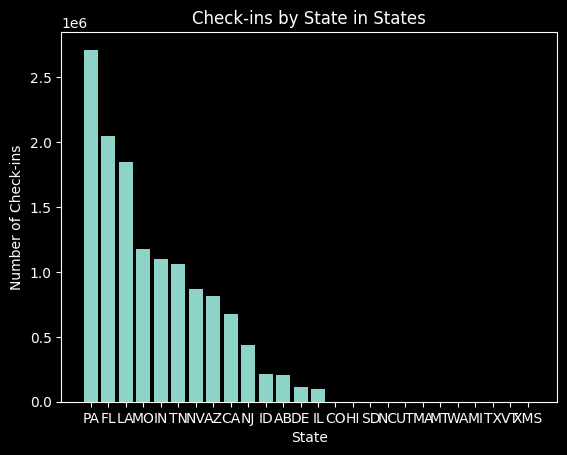

In [56]:
df_count =df_exploded.groupby("state").size().sort_values(ascending=False).reset_index(name = "count")
plt.bar(df_count["state"], df_count["count"])
plt.xlabel("State")
plt.ylabel("Number of Check-ins")
plt.title("Check-ins by State in States")
plt.show()


In [34]:
df_exploded["hour"] = df_exploded["check_in_list"].dt.hour
df_exploded["day"] = df_exploded["check_in_list"].dt.day

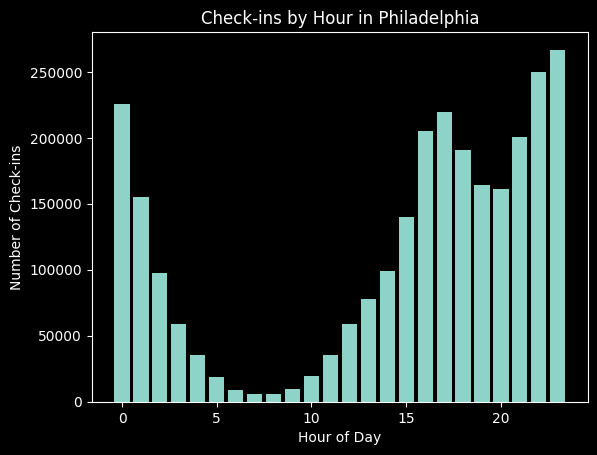

In [47]:
state_traffic = df_exploded[df_exploded["state"] == "PA"].groupby("hour").size().sort_values(ascending=False).reset_index(name = "count")
hours = state_traffic["hour"].tolist()
plt.bar(state_traffic["hour"], state_traffic["count"])
plt.xlabel("Hour of Day")
plt.ylabel("Number of Check-ins")
plt.title("Check-ins by Hour in Philadelphia")
plt.show()